In [1]:
import pandas as pd

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

file_path = DATA_DIR / "clean_sales_data.csv"

df = pd.read_csv(file_path)

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,City,ProductID,ProductName,Category,Quantity,UnitPrice,DiscountPercentage,DiscountAmount,PaymentMethod,TotalSales
0,ORD01611,2025-01-01,C0039,Sahan Samarasinghe,Negombo,P007,Office Desk,Furniture,4,55000,0,0.0,Cash,220000.0
1,ORD01773,2025-01-01,C0156,Nethmi Gunawardena,Batticaloa,P006,Office Chair,Furniture,1,35000,10,3500.0,Credit Card,31500.0
2,ORD01966,2025-01-01,C0219,Dilini Jayasinghe,Anuradhapura,P018,Blender,Home Appliances,2,14000,0,0.0,Cash,28000.0
3,ORD01792,2025-01-01,C0458,Hiruni Fernando,Anuradhapura,P005,Smart Watch,Electronics,4,25000,5,5000.0,Credit Card,95000.0
4,ORD01451,2025-01-01,C0166,Kasun Perera,Galle,P017,Electric Kettle,Home Appliances,3,8500,10,2550.0,Online Payment,22950.0


In [3]:
df.shape

(3000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   OrderID             3000 non-null   str    
 1   OrderDate           3000 non-null   str    
 2   CustomerID          3000 non-null   str    
 3   CustomerName        3000 non-null   str    
 4   City                3000 non-null   str    
 5   ProductID           3000 non-null   str    
 6   ProductName         3000 non-null   str    
 7   Category            3000 non-null   str    
 8   Quantity            3000 non-null   int64  
 9   UnitPrice           3000 non-null   int64  
 10  DiscountPercentage  3000 non-null   int64  
 11  DiscountAmount      3000 non-null   float64
 12  PaymentMethod       3000 non-null   str    
 13  TotalSales          3000 non-null   float64
dtypes: float64(2), int64(3), str(9)
memory usage: 328.3 KB


In [5]:
df.describe()

,Quantity,UnitPrice,DiscountPercentage,DiscountAmount,TotalSales
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1.903667,31434.450000,5.493333,3341.970833,56330.129167
std,1.092147,40141.486025,5.272497,8380.806886,89272.796439
min,1.000000,650.000000,0.000000,0.000000,552.500000
25%,1.000000,4500.000000,0.000000,0.000000,7125.000000
50%,2.000000,18000.000000,5.000000,360.000000,24000.000000
75%,3.000000,42000.000000,10.000000,3250.000000,66500.000000
max,5.000000,180000.000000,15.000000,135000.000000,855000.000000


In [6]:
total_revenue = df["TotalSales"].sum()

print(f"Total Revenue: LKR {total_revenue:,.2f}")

Total Revenue: LKR 168,990,387.50


In [7]:
top_products = (
    df.groupby("ProductName")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

ProductName
Notebook               270
Dining Table           269
Wireless Headphones    262
Calculator             257
File Folder            256
Pen Set                249
Desk Organizer         242
Laptop                 240
Tablet                 235
Smart Watch            234
Name: Quantity, dtype: int64

In [8]:
category_sales = (
    df.groupby("Category")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales


Category
Electronics        82124900.0
Furniture          53402950.0
Home Appliances    22615600.0
Clothing            9180475.0
Stationery          1666462.5
Name: TotalSales, dtype: float64

In [9]:
city_sales = (
    df.groupby("City")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)

city_sales

City
Galle           19644162.5
Ratnapura       19494920.0
Matara          17105032.5
Jaffna          16989470.0
Batticaloa      16475465.0
Kandy           16378515.0
Kurunegala      16127652.5
Colombo         15886435.0
Anuradhapura    15471765.0
Negombo         15416970.0
Name: TotalSales, dtype: float64

In [10]:
payment_sales = (
    df.groupby("PaymentMethod")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)

payment_sales

PaymentMethod
Credit Card       45236685.0
Cash              42656520.0
Online Payment    41509617.5
Debit Card        39587565.0
Name: TotalSales, dtype: float64

In [11]:
import matplotlib.pyplot as plt

In [12]:
category_sales = (
    df.groupby("Category")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Electronics        82124900.0
Furniture          53402950.0
Home Appliances    22615600.0
Clothing            9180475.0
Stationery          1666462.5
Name: TotalSales, dtype: float64

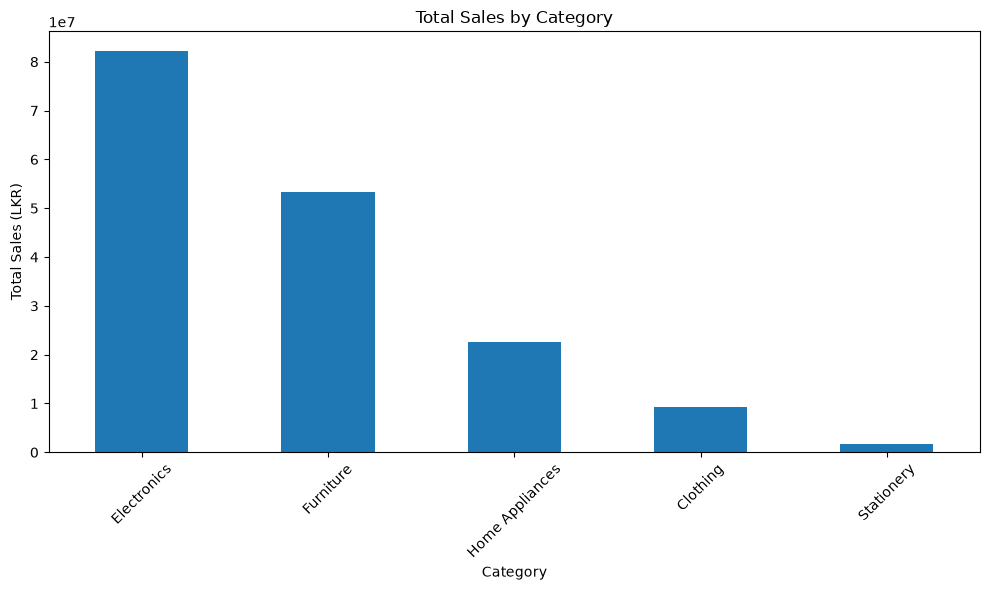

In [13]:
category_sales.plot(
    kind="bar",
    title="Total Sales by Category",
    figsize=(10, 6)
)

plt.xlabel("Category")
plt.ylabel("Total Sales (LKR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
top_products = (
    df.groupby("ProductName")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

ProductName
Notebook               270
Dining Table           269
Wireless Headphones    262
Calculator             257
File Folder            256
Pen Set                249
Desk Organizer         242
Laptop                 240
Tablet                 235
Smart Watch            234
Name: Quantity, dtype: int64

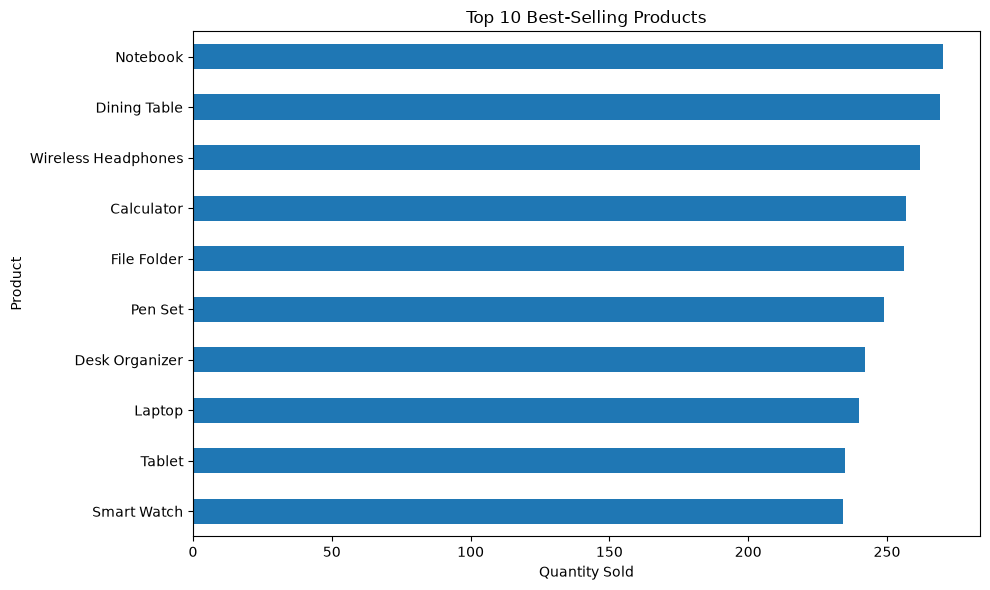

In [15]:
top_products.sort_values().plot(
    kind="barh",
    title="Top 10 Best-Selling Products",
    figsize=(10, 6)
)

plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [16]:
city_sales = (
    df.groupby("City")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)

city_sales

City
Galle           19644162.5
Ratnapura       19494920.0
Matara          17105032.5
Jaffna          16989470.0
Batticaloa      16475465.0
Kandy           16378515.0
Kurunegala      16127652.5
Colombo         15886435.0
Anuradhapura    15471765.0
Negombo         15416970.0
Name: TotalSales, dtype: float64

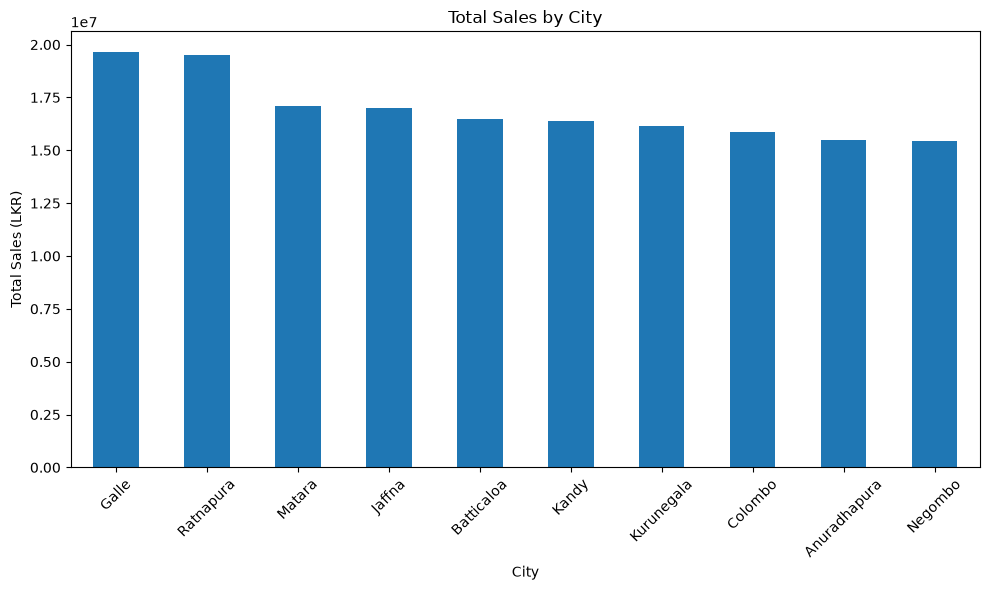

In [17]:
city_sales.plot(
    kind="bar",
    title="Total Sales by City",
    figsize=(10, 6)
)

plt.xlabel("City")
plt.ylabel("Total Sales (LKR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
payment_sales = (
    df.groupby("PaymentMethod")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)

payment_sales

PaymentMethod
Credit Card       45236685.0
Cash              42656520.0
Online Payment    41509617.5
Debit Card        39587565.0
Name: TotalSales, dtype: float64

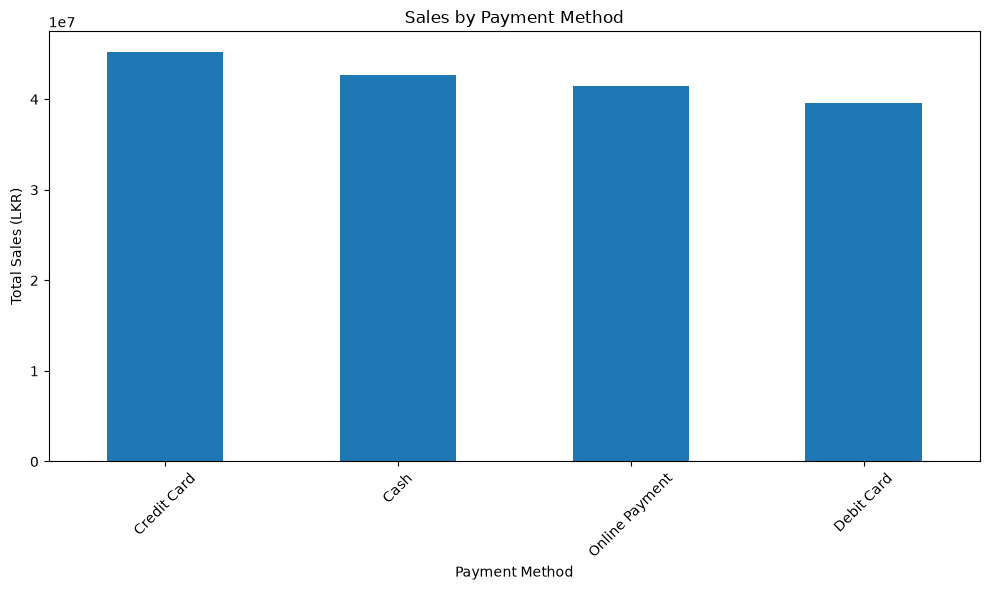

In [19]:
payment_sales.plot(
    kind="bar",
    title="Sales by Payment Method",
    figsize=(10, 6)
)

plt.xlabel("Payment Method")
plt.ylabel("Total Sales (LKR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

monthly_sales = (
    df.groupby(df["OrderDate"].dt.to_period("M"))["TotalSales"]
    .sum()
)

monthly_sales

OrderDate
2025-01     8587900.0
2025-02     9024545.0
2025-03     6797015.0
2025-04     7865052.5
2025-05     9006362.5
2025-06     6469620.0
2025-07    10673435.0
2025-08     7925955.0
2025-09     6554402.5
2025-10     7047232.5
2025-11     9457617.5
2025-12     8343817.5
2026-01     8304332.5
2026-02     8682352.5
2026-03     9859480.0
2026-04     8645115.0
2026-05    10344875.0
2026-06     9055937.5
2026-07    10209170.0
2026-08     6136170.0
Freq: M, Name: TotalSales, dtype: float64

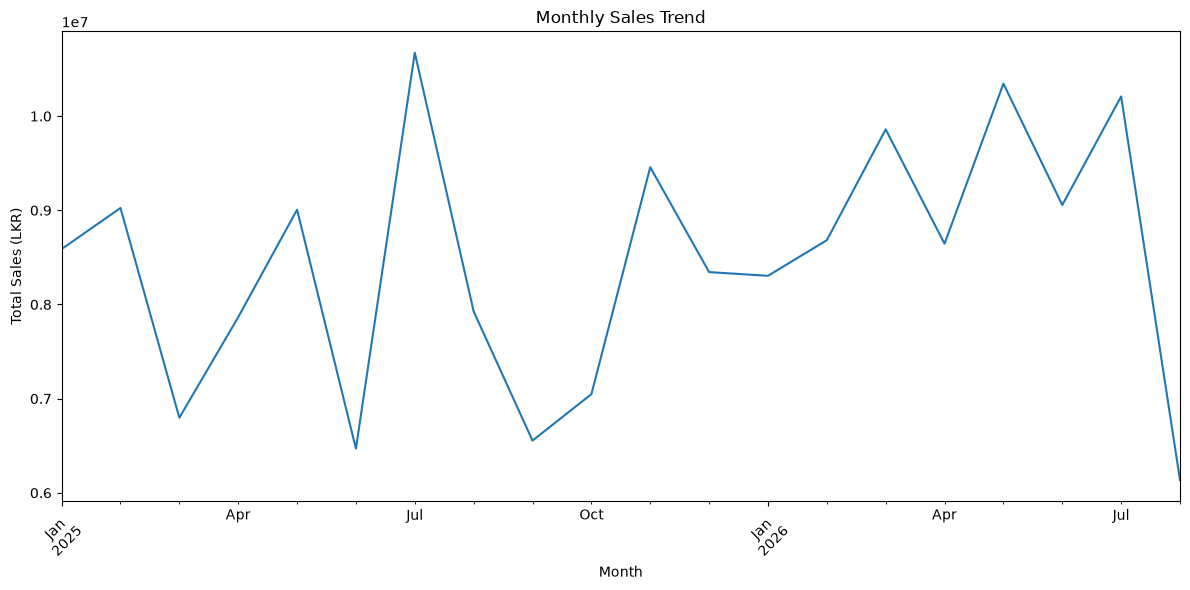

In [21]:
monthly_sales.plot(
    kind="line",
    title="Monthly Sales Trend",
    figsize=(12, 6)
)

plt.xlabel("Month")
plt.ylabel("Total Sales (LKR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()